In [5]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');
download('https://github.com/ramalho/jupyturtle/releases/download/2024-03/jupyturtle.py');

Downloaded thinkpython.py
Downloaded jupyturtle.py


In [6]:
import thinkpython

%load_ext autoreload
%autoreload 2

In [7]:
import jupyturtle

In [11]:
jupyturtle.make_turtle()
jupyturtle.forward(100)

In [12]:
from jupyturtle import make_turtle, forward

In [13]:
make_turtle()
forward(100)

In [14]:
from jupyturtle import left, right

In [20]:
make_turtle()
forward(20)
left(90)
forward(50)
right(45)
forward(10)

In [21]:
# make a square
make_turtle()
forward(50)
right(90)
forward(50)
right(90)
forward(50)
right(90)
forward(50)

In [22]:
make_turtle()
for i in range(4):
    forward(50)
    right(90)   

In [23]:
def square():
    for i in range(4):
        forward(50)
        right(90)

In [24]:
make_turtle()
square()

In [26]:
def square(length):
    for i in range(4):
        forward(length)
        right(90)   

In [27]:
make_turtle()
square(20)

In [28]:
def polygon(n, length):
    angle = 360/n
    for i in range(n):
        forward(length)
        left(angle)

In [33]:
make_turtle()
polygon(7, 20)

In [32]:
make_turtle()
polygon(3, 50)

In [35]:
make_turtle()
polygon(n=10,length=15)

In [36]:
import math
def circle(radius):
    circumference = 2 * math.pi * radius
    n = 100
    length =  circumference / n
    polygon(n, length)

In [41]:
make_turtle(delay=0.02)
circle(20)

In [42]:
def polyline(n, length, angle):
    for i in range(n):
        forward(length)
        left(angle)

In [43]:
def polygon(n, length):
    angle = 360.0/n
    polyline(n, length, angle)
    

In [73]:
def arc(radius, angle):
    arc_length = 2 * math.pi * radius * angle / 360
    n = 3
    length = arc_length / n
    step_angle = angle / n
    polyline(n, length, step_angle)

In [74]:
make_turtle(delay=0)
arc(30, 90)

In [75]:
def circle(radius):
    arc(radius, 360)

In [76]:
make_turtle(delay=0)
polygon(n= 5, length=10)
arc(radius= 60, angle = 70)
circle(radius= 10)

In [88]:
from diagram import make_binding, make_frame, Frame, Stack

frame1 = make_frame(dict(radius=30), name = 'circle', loc ='left')

frame2 = make_frame(dict(radius=30, angle = 360), name = 'arc', loc = 'left', dx = 1.1)

frame3 = make_frame(dict(n=60, length = 3, angle = 5.8),
                    name = 'polyline', loc='left', dx=1, offsetx = -0.27)

stack = Stack([frame1, frame2, frame3], dy = -0.4)

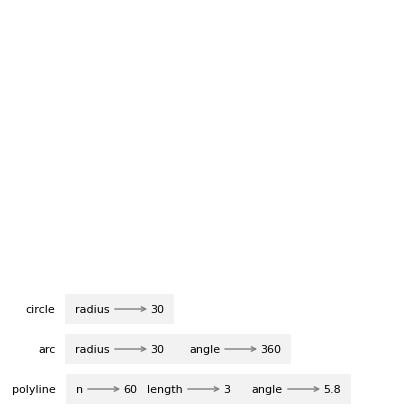

In [92]:
from diagram import diagram, adjust

width, height, x, y = [ 4, 4 ,1, 1,]
ax = diagram(width, height)
bbox = stack.draw(ax, x, y)

In [93]:
%xmode Verbose

Exception reporting mode: Verbose


In [120]:
from jupyturtle import penup, pendown

def jump(length):
    """ Move forward length units without leaving a trail.
    Postcondition: Leaves the pen Down. """
    
    penup()
    forward(length)
    pendwon()

In [121]:
def rectangle(width, height):
    for i in range(2):
        forward(width)
        right(90)
        forward(height)
        right(90)

In [109]:
make_turtle()
rectangle(50, 50)

In [110]:
def rhombus(length,  angle):
    for i in range(2):
        forward(length)
        right(angle)
        forward(length)
        right(180-angle)
    

In [111]:
make_turtle()
rhombus(50,123)

In [112]:
def parallelogram(length,height, angle):
    for i in range(2):
        forward(length)
        right(angle)
        forward(height)
        right(180-angle)
        
    

In [113]:
def rectangle(width, height):
    parallelogram(width,height, 90)

In [115]:
make_turtle()
rectangle(50, 30)

In [116]:
def rhombus(length, angle):
    parallelogram(length,length, angle)

In [118]:
make_turtle()
rhombus(50, 123)

In [123]:
from jupyturtle import penup, pendown

def jump(length):
    """ Move forward length units without leaving a trail.
    Postcondition: Leaves the pen Down. """
    
    penup()
    forward(length)
    pendown()

In [124]:
make_turtle(width=400)
jump(-120)

In [178]:
import math

def triangle(length, angle):
    # 计算等腰三角形的底角
    side_angle = (180 - angle) / 2
    
    # 1. 画第一条半径
    forward(length)
    
    # 2. 转弯准备画底边 (转外角)
    left(180 - side_angle)
    
    # 3. 画底边
    # 底边长度公式：2 * length * sin(angle/2)
    # 如果不想用公式，可以尝试一个固定数值调试，但公式最准
    dist = 2 * length * math.sin(math.radians(angle / 2))
    forward(dist)
    
    # 4. 转弯准备回圆心
    left(180 - side_angle)
    
    # 5. 画第二条半径回到圆心
    forward(length)
    
    # 6. 最后一步极其重要：把海龟转回起始方向，并再转动 angle
    # 这样 draw_pie 里的循环才能无缝衔接
    left(180)

In [179]:
def draw_pie(n, size):
    angle = 360 / n
    for i in range(n):
        triangle(size, angle)
        # 注意：如果 triangle 内部已经转过 angle 了，这里就不需要再 left(angle) 了

In [180]:
make_turtle(delay=0)
angle = 50
size = 50
draw_pie(7,size)

In [181]:
turtle = make_turtle(delay=0)
jump(-80)

size = 40
draw_pie(5, size)
jump(2*size)
draw_pie(6, size)
jump(2*size)
draw_pie(7, size)

In [189]:
def arc(radius, angle):
    arc_length = 2 * math.pi * radius * angle / 360
    n = 30
    length = arc_length / n
    step_angle = angle / n
    polyline(n, length, step_angle)

In [190]:
def petal(radius, angle):
    """
    画一个由两条弧线组成的花瓣
    radius: 弧线所属圆的半径
    angle: 弧线的圆心角（决定花瓣的胖瘦）
    """
    for i in range(2):
        arc(radius, angle)  # 画第一条弧线
        left(180 - angle)   # 转向，准备画第二条对称的弧线

In [191]:
def flower(n, radius, angle):
    """
    画一朵由 n 片花瓣组成的花
    n: 花瓣的数量
    radius: 花瓣弧线的半径
    angle: 每片花瓣弧线的角度
    """
    for i in range(n):
        petal(radius, angle)  # 调用我们第一步定义的函数
        left(360 / n)         # 旋转出下一片花瓣的位置

In [198]:
from jupyturtle import render

turtle = make_turtle(auto_render=True,delay= 0.01)

jump(-60)
n = 7
radius = 60
angle = 60
flower(n, radius, angle)

jump(120)
n = 9
radius = 40
angle = 85
flower(n, radius, angle)

render()

In [199]:
from jupyturtle import make_turtle, forward, left, render

def spiral(n, length, a, angle):
    """
    绘制一个螺旋线
    n: 线段的数量
    length: 初始线段长度
    a: 每次循环步长的增量（决定螺旋散开的速度）
    angle: 每次旋转的角度（决定螺旋的紧凑程度）
    """
    for i in range(n):
        forward(length)
        left(angle)
        # 核心：让下一次前进的距离变长一点点
        length = length + a

# 测试代码
make_turtle(delay=0)
# 画一个 200 步的螺旋，起始长度 0.1，每次增加 0.1，转动 15 度
spiral(200, 0.1, 0.1, 15)
render()